# Scikit-Learn Models

This notebook demonstrates how to train one of the Scikit-Learn models included in our SklearnModels wrapper using the 3W dataset for Multiclass Classification with Time Series data using the ThreeWToolkit.

In [1]:
from ThreeWToolkit.trainer import SklearnTrainerConfig
from ThreeWToolkit.models import SklearnModelsConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.utils import TrainTestSplitter
import ThreeWToolkit.preprocessing as preprocessing
import ThreeWToolkit.feature_extraction as features

from ThreeWToolkit.assessment import (
    AssessmentVisualizationConfig,
    ModelAssessmentConfig,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 2026

## Loading and preparing the Dataset
The next step is to create a ParqueDataset instance to interact with the 3W dataset, for that we have to define a path location where we want to save the Dataset to (or where it is already located).

In [2]:
# Modify this path to the folder where your dataset is downloaded
dataset_path = "../../dataset"
event_types = ["real", "simulated"] # lets use only real/simulated events
threew_dataset = ParquetDatasetConfig(path=dataset_path, event_type=event_types).build()

splitter = TrainTestSplitter(size_test=0.2, stratify_by=["event_type", "event_class"])
ds_train, ds_test = splitter.split_data(threew_dataset) #first split for training/test
ds_train, ds_val  = splitter.split_data(ds_train) # split again for training'/validation

2026-04-21 19:39:27,251 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-21 19:39:27,252 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-21 19:39:27,253 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [3]:
len(ds_train), len(ds_val), len(ds_test)

(1412, 354, 442)

In [5]:
wavelet_level = 7
window_size = 2**wavelet_level
dataset_processor = TransformConfig(
    pre_processing=preprocessing.SequentialPreprocessingAdapterConfig(
        steps=[
            preprocessing.CleanSignalsConfig(missing_column_threshold=0.65),
            preprocessing.ImputeMissingConfig(),
            preprocessing.NormalizeConfig(),
            preprocessing.FillLabelsConfig(),
            preprocessing.RemapClassConfig(),
        ]
    ),
    feature_extraction=features.SequentialFeatureAdapterConfig(
        steps=[
            features.WindowingConfig(window_size=window_size),
            features.ConcatFeatureAdapterConfig(
                steps=[features.StatisticalConfig(),
                       features.EWStatisticalConfig(window_size=window_size),
                       features.WaveletConfig(level=wavelet_level)]
            ),
        ]
    ),
).build()

dataset_processor.fit(ds_train)
ds_train_transformed = dataset_processor.transform(ds_train)
ds_val_transformed = dataset_processor.transform(ds_val)
ds_test_transformed = dataset_processor.transform(ds_test)

In [29]:
# lets keep a reference for the label remapper so we can translate classes later
label_mapper = dataset_processor.pre_processing_step.steps[4]

## Model Trainer Configurations

With the data ready, we are now able to define the `ModelTrainer`, using using the SkLearnModelsConfig and TrainerConfig configuration classes.

Very important to note that the TrainerConfig class receives as a parameter the model configuration (config_model), and we use this information to instantiate `ModelTrainer`.

In [6]:
# First, create the configuration for the specific scikit-learn model you want to use.
from sklearn.ensemble import RandomForestClassifier

sklearn_config = SklearnModelsConfig(
    model_type=RandomForestClassifier,
    model_params={"n_estimators": 100, "max_depth": 10},
)

trainer = SklearnTrainerConfig(
    config_model=sklearn_config,
).build()

print("ModelTrainer configured for RandomForestClassifier:")
print(trainer.model)

2026-04-21 19:47:41,498 | INFO | ThreeWToolkit.core.base_trainer | Initialized SklearnTrainer with seed=42
2026-04-21 19:47:41,499 | INFO | ThreeWToolkit.trainer.sklearn_trainer | SklearnTrainer initialized | model=RandomForestClassifier | n_jobs=20


ModelTrainer configured for RandomForestClassifier:


## Training the model

With the data and Trainer ready, we can call the trainer.train() method while passing the x_train and y_train argument.

In [7]:
train_results = trainer.train(
    train_dataset=ds_train_transformed, val_dataset=ds_val_transformed
)

2026-04-21 19:48:13,149 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=1412 | val_size=354
2026-04-21 19:48:13,267 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-21 19:48:13,268 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-21 19:48:13,269 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Converting dataset to arrays (size=1412)
2026-04-21 19:50:33,321 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Created arrays | X.shape=(366454, 448) | y.shape=(366454,)
2026-04-21 19:50:33,326 | INFO | ThreeWToolkit.core.base_trainer | Preparing validation data...
2026-04-21 19:50:33,327 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Converting dataset to arrays (size=354)
2026-04-21 19:51:09,479 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Created arrays | X.shape=(98598, 448) | y.shape=(98598,)
2026-04-21 19:51:09,482 | INFO | ThreeWToolkit.core.base_trainer | Initializing training state...
2026-04-21 1

## Training Assessment and Results

For gathering the results using the test set, we will use the ModelAssessmentConfig inside the trainer.assess method.

In [8]:
test_results = trainer.predict(ds_test_transformed)

# Evaluate model performance on validation set using ModelTrainer's test method
assessment = ModelAssessmentConfig(
    metrics=["accuracy"],
).build()

results = assessment.evaluate(training_results=train_results, predictions=test_results)

2026-04-21 19:51:39,042 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Converting dataset to arrays (size=442)
2026-04-21 19:52:21,396 | INFO | ThreeWToolkit.trainer.sklearn_trainer | Created arrays | X.shape=(110921, 448) | y.shape=(110921,)
2026-04-21 19:52:22,062 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /home/thadeu-dias/Documents/3W/toolkit/output/exp_20260421_1952
2026-04-21 19:52:22,063 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: SklearnModels
Task Type: classification
Timestamp: 20260421_1952

Metrics:
  accuracy: 0.9209

Training History:
  Final train_loss: 0.9508
  Final val_loss: 0.9190


We got a decent accuracy!

Since sklearn models dont usually have `epochs', lets see how the model behaves with the test subset.

We have a visualization method built in, but we may choose to customize our plots.
Lets plot a confusion matrix of the test results using sklearn/matplotlib:

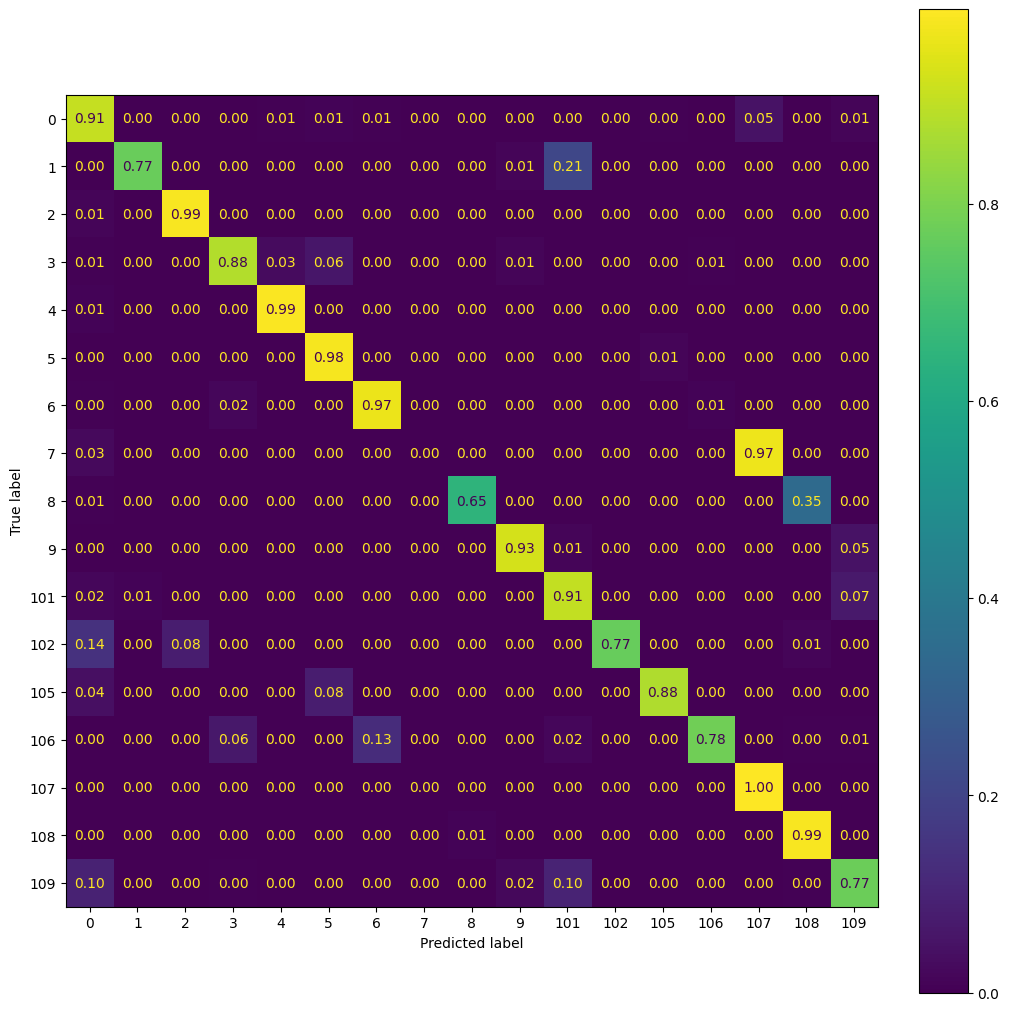

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# recover the true labels!
original_labels = [int(k) for k in label_mapper.class_map.keys()]

fig, ax = plt.subplots(figsize=(10, 10), layout='constrained')
ConfusionMatrixDisplay.from_predictions(results.true_values, results.predictions,
                                        normalize='true', ax=ax, values_format='.2f',
                                        display_labels=original_labels);

Apparently, we can identify the fault classes correctly, but we mistake transients for steady-state faults (7 vs. 107, 8 vs 108), and so on.